In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import numpy as np

class Activation:
    def __init__(self, name: str):
        self.name = name

        self.functions = {
            'sigmoid': self.sigmoid,
            'tanh': np.tanh,
            'relu': self.relu,
            'linear': lambda x: x,
            'softmax': self.softmax,
            'binary_step': lambda x: np.where(x >= 0, 1, 0)
        }

        self.derivatives = {
            'sigmoid': lambda out: out * (1 - out),
            'tanh': lambda out: 1 - out**2,
            'relu': self.relu_derivative,
            'linear': lambda out: np.ones_like(out),
            'softmax': lambda out: np.ones_like(out),
            'binary_step': lambda out: np.zeros_like(out)
        }

        if name not in self.functions:
            raise ValueError(f"Activation '{name}' not defined")

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.input = x
        self.output = self.functions[self.name](x)
        return self.output

    def derivative(self) -> np.ndarray:
        return self.derivatives[self.name](self.output)

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        return grad_output * self.derivative()


    @staticmethod
    def sigmoid(x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def relu(x: np.ndarray) -> np.ndarray:
        return np.maximum(0, x)

    @staticmethod
    def softmax(x: np.ndarray) -> np.ndarray:
        exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

    def relu_derivative(self, out: np.ndarray) -> np.ndarray:
        return np.where(self.input > 0, 1, 0)

In [6]:
class Loss:
    def __init__(self, name: str):
        self.name = name

        self.functions = {
            'mse': lambda y_true, y_pred: np.mean((y_true - y_pred)**2),
            'cross_entropy': self.cross_entropy,
            'categorical_cross_entropy': self.categorical_cross_entropy,
        }

        self.derivatives = {
            'mse': lambda y_true, y_pred: 2 * (y_pred - y_true) / y_true.shape[0],
            'cross_entropy': self.cross_entropy_derivative,
            'categorical_cross_entropy': lambda y_true, y_pred: (y_pred - y_true) / y_true.shape[0]
        }

        if name not in self.functions:
            raise ValueError(f"Loss '{name}' not define.")

    def forward(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return self.functions[self.name](y_true, y_pred)

    def derivative(self, y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        return self.derivatives[self.name](y_true, y_pred)

    @staticmethod
    def cross_entropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    @staticmethod
    def categorical_cross_entropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    @staticmethod
    def cross_entropy_derivative(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return (y_pred - y_true) / (y_true.shape[0] * y_pred * (1 - y_pred))


In [7]:
class ActivationLayer:
    def __init__(self, activation: str):
        self.activation = Activation(activation)
        self.output = None
        self.input = None


    def forward(self, inputs: np.ndarray) -> np.ndarray:
        self.input = inputs
        self.output = self.activation.forward(inputs)
        return self.output

    def backward(self, output_error: np.ndarray, learning_rate: float = None) -> np.ndarray:
        return output_error * self.activation.derivative()

In [8]:
class Layer:
    def __init__(self, num_neurons, num_inputs):
        self.num_neurons = num_neurons
        self.num_inputs = num_inputs

        self.weights = np.random.uniform(-1, 1, (num_neurons, num_inputs))
        self.bias = np.random.uniform(-1, 1, (1, num_neurons))

        self.input = None
        self.output = None

        self.m_w = np.zeros_like(self.weights)
        self.v_w = np.zeros_like(self.weights)
        self.m_b = np.zeros_like(self.bias)
        self.v_b = np.zeros_like(self.bias)
        self.t = 0

    def forward(self, inputs: np.ndarray) -> np.ndarray:
        inputs = np.atleast_2d(inputs)
        self.input = inputs
        self.output = inputs @ self.weights.T + self.bias
        return self.output

    def backward(self, output_error: np.ndarray, learning_rate: float,
                 beta1: float = 0.9, beta2: float = 0.999, epsilon: float = 1e-8) -> np.ndarray:

        self.t += 1
        batch_size = self.input.shape[0]

        weight_gradient = (output_error.T @ self.input) / batch_size
        bias_gradient = output_error.mean(axis=0, keepdims=True)

        self.m_w = beta1 * self.m_w + (1 - beta1) * weight_gradient
        self.m_b = beta1 * self.m_b + (1 - beta1) * bias_gradient

        self.v_w = beta2 * self.v_w + (1 - beta2) * (weight_gradient ** 2)
        self.v_b = beta2 * self.v_b + (1 - beta2) * (bias_gradient ** 2)

        m_hat_w = self.m_w / (1 - beta1 ** self.t)
        v_hat_w = self.v_w / (1 - beta2 ** self.t)
        m_hat_b = self.m_b / (1 - beta1 ** self.t)
        v_hat_b = self.v_b / (1 - beta2 ** self.t)

        self.weights -= learning_rate * m_hat_w / (np.sqrt(v_hat_w) + epsilon)
        self.bias -= learning_rate * m_hat_b / (np.sqrt(v_hat_b) + epsilon)

        return output_error @ self.weights

In [9]:
class MLP:
    def __init__(self, layers: list, loss_name: str = "mse"):
        self.layers: list= layers
        self.loss = Loss(loss_name)

    def forward(self, inputs: np.ndarray) -> np.ndarray:
        output = inputs

        for layer in self.layers:
            output = layer.forward(output)
        return output

    def backward(self, inputs: np.ndarray, targets: np.ndarray, learning_rate: float) -> float:
        predictions = self.forward(inputs)
        error_gradient = self.loss.derivative(targets, predictions)

        for layer in reversed(self.layers):
          error_gradient = layer.backward(error_gradient, learning_rate)

        return self.loss.forward(targets, predictions)

    def train(self,inputs: np.ndarray,targets: np.ndarray,learning_rate: float = 0.01,epochs: int = 100,debug: bool = False) -> list[float]:
        loss_history = [] if debug else None

        for epoch in range(epochs):
            loss_value = self.backward(inputs, targets, learning_rate)
            if debug:
                loss_history.append(loss_value)
            if epoch % 10 == 0:
                print(f"Epoch {epoch}, Loss: {loss_value}")

        return loss_history


In [10]:
def plot_loss(loss_history, title):
    plt.figure(figsize=(6,4))
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True)
    plt.show()

def show_predictions(model, inputs, name):
    print(f"\n{name} predictions")

    for x in inputs:
        prediction = model.forward(np.array([x]))
        print(f"{x} -> {np.round(prediction)}")

def check_accuracy(model, inputs, targets):
    correct = 0

    for x, y in zip(inputs, targets):
        prediction = np.round(model.forward(np.array([x])))
        if (prediction == y).all():
            correct += 1

    accuracy = correct / len(inputs)

    print(f"Accuracy: {accuracy:.2f}")

    return accuracy

Epoch 0, Loss: 0.6883404139117443
Epoch 10, Loss: 0.09091748354667002
Epoch 20, Loss: 0.07148048931044353
Epoch 30, Loss: 0.06447512078524309
Epoch 40, Loss: 0.0627332648365051
Epoch 50, Loss: 0.06300695176170994
Epoch 60, Loss: 0.06306459046922445
Epoch 70, Loss: 0.06267181430705136
Epoch 80, Loss: 0.06250149575435576
Epoch 90, Loss: 0.0625243658973027


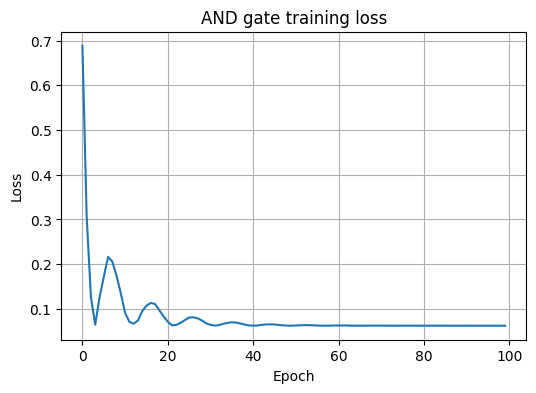


AND gate predictions
[0 0] -> [[-0.]]
[0 1] -> [[0.]]
[1 0] -> [[0.]]
[1 1] -> [[1.]]
Accuracy: 1.00


In [11]:
and_inputs = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

and_targets = np.array([
    [0],
    [0],
    [0],
    [1]
])

and_layers = [
    Layer(num_neurons=1, num_inputs=2),
    ActivationLayer("linear")
]

and_mlp = MLP(and_layers)
and_loss = and_mlp.train(and_inputs, and_targets, learning_rate=0.5, epochs=100, debug=True)

plot_loss(and_loss, "AND gate training loss")
show_predictions(and_mlp, and_inputs, "AND gate")
and_accuracy = check_accuracy(and_mlp, and_inputs, and_targets)

Epoch 0, Loss: 0.7248849344014099
Epoch 10, Loss: 0.20144258100542023
Epoch 20, Loss: 0.11123700376065675
Epoch 30, Loss: 0.06563534561935763
Epoch 40, Loss: 0.07002190071114621
Epoch 50, Loss: 0.06470585066850162
Epoch 60, Loss: 0.06306015199759213
Epoch 70, Loss: 0.06270247953153546
Epoch 80, Loss: 0.06263230669788036
Epoch 90, Loss: 0.06255992865724816


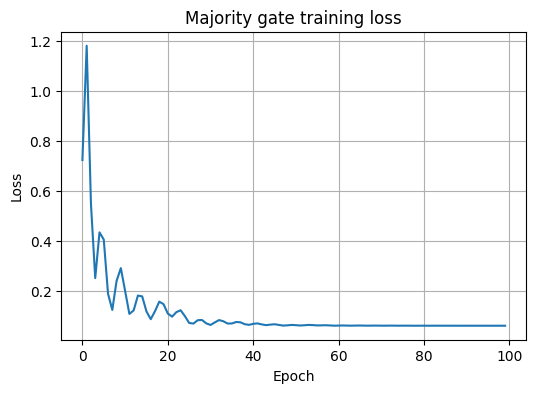


Majority gate predictions
[0 0 0] -> [[-0.]]
[0 0 1] -> [[0.]]
[0 1 0] -> [[0.]]
[0 1 1] -> [[1.]]
[1 0 0] -> [[0.]]
[1 0 1] -> [[1.]]
[1 1 0] -> [[1.]]
[1 1 1] -> [[1.]]
Accuracy: 1.00
Majority gate accuracy: 100.00%


In [12]:
majority_inputs = np.array([
    [0,0,0],
    [0,0,1],
    [0,1,0],
    [0,1,1],
    [1,0,0],
    [1,0,1],
    [1,1,0],
    [1,1,1]
])

majority_targets = np.array([
    [0],
    [0],
    [0],
    [1],
    [0],
    [1],
    [1],
    [1]
])
majority_layers = [
    Layer(num_neurons=1, num_inputs=3),
    ActivationLayer("linear")
]

majority_mlp = MLP(majority_layers)
majority_loss = majority_mlp.train(majority_inputs,majority_targets,learning_rate=0.5,epochs=100,debug=True)


plot_loss(majority_loss, "Majority gate training loss")
show_predictions(majority_mlp, majority_inputs, "Majority gate")

majority_accuracy = check_accuracy(majority_mlp, majority_inputs, majority_targets)
print(f"Majority gate accuracy: {majority_accuracy*100:.2f}%")

Epoch 0, Loss: 0.28327786895219254
Epoch 10, Loss: 0.22960298092963893
Epoch 20, Loss: 0.1749818277109258
Epoch 30, Loss: 0.16739878055746435
Epoch 40, Loss: 0.16439806132210671
Epoch 50, Loss: 0.13196666777192112
Epoch 60, Loss: 0.018917369849108013
Epoch 70, Loss: 0.0019255314567862823
Epoch 80, Loss: 0.000762196483884056
Epoch 90, Loss: 0.00047268627350149743
Epoch 100, Loss: 0.0003733630708943208
Epoch 110, Loss: 0.00032390320489003956
Epoch 120, Loss: 0.00029191776611782894
Epoch 130, Loss: 0.0002677498152475152
Epoch 140, Loss: 0.000247855765890023
Epoch 150, Loss: 0.00023078234127435495
Epoch 160, Loss: 0.00021580074598194986
Epoch 170, Loss: 0.0002024744960350977
Epoch 180, Loss: 0.00019051678728288917
Epoch 190, Loss: 0.00017972124549380647
Epoch 200, Loss: 0.00016992721436835299
Epoch 210, Loss: 0.00016100410471068627
Epoch 220, Loss: 0.0001528435454661808
Epoch 230, Loss: 0.0001453544888982174
Epoch 240, Loss: 0.00013845975840394922
Epoch 250, Loss: 0.00013209347432636558
Ep

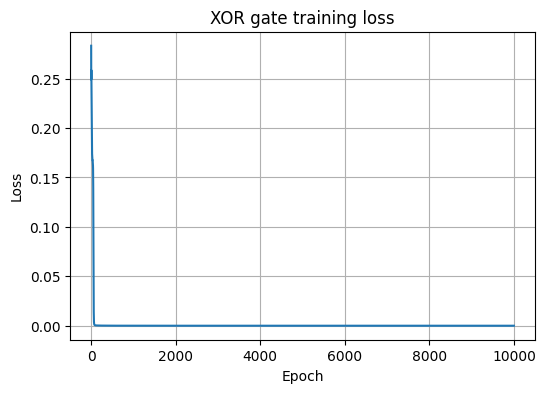


XOR gate predictions
[0 0] -> [[0.]]
[0 1] -> [[1.]]
[1 0] -> [[1.]]
[1 1] -> [[0.]]
Accuracy: 1.00
XOR gate accuracy: 100.00%


In [16]:

xor_inputs = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

xor_targets = np.array([
    [0],
    [1],
    [1],
    [0]
])

xor_layers = [
    Layer(num_neurons=2, num_inputs=2),
    ActivationLayer("sigmoid"),
    Layer(num_neurons=1, num_inputs=2),
    ActivationLayer("sigmoid")
]

xor_mlp = MLP(xor_layers)


xor_loss = xor_mlp.train(xor_inputs,xor_targets,learning_rate=0.3,epochs=10000, debug=True)

plot_loss(xor_loss, "XOR gate training loss")
show_predictions(xor_mlp, xor_inputs, "XOR gate")

xor_accuracy = check_accuracy(xor_mlp, xor_inputs, xor_targets)
print(f"XOR gate accuracy: {xor_accuracy*100:.2f}%")